# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
data = pd.read_csv("../MSFT-Stock_raw.csv")
data.head()

,Date,Close,High,Low,Open,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,...,Year,Month,Quarter,Day_of_Week,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle
0,1986-03-13,0.0593,0.0619,0.0540,0.0540,1031788800,NaN,0.0079,NaN,NaN,...,1986,3,1,Thursday,NaN,0.0000,0.0000,NaN,NaN,NaN
1,1986-03-14,0.0614,0.0624,0.0593,0.0593,308160000,3.5413,0.0031,NaN,NaN,...,1986,3,1,Friday,NaN,0.0002,0.0000,NaN,NaN,NaN
2,1986-03-17,0.0624,0.0630,0.0614,0.0614,133171200,1.6287,0.0016,NaN,NaN,...,1986,3,1,Monday,NaN,0.0004,0.0001,NaN,NaN,NaN
3,1986-03-18,0.0608,0.0630,0.0603,0.0624,67766400,-2.5641,0.0027,NaN,NaN,...,1986,3,1,Tuesday,NaN,0.0004,0.0002,NaN,NaN,NaN
4,1986-03-19,0.0598,0.0614,0.0593,0.0608,47894400,-1.6447,0.0021,NaN,NaN,...,1986,3,1,Wednesday,NaN,0.0003,0.0002,NaN,NaN,NaN


In [7]:
data.shape

(10072, 23)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10072 entries, 0 to 10071
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              10072 non-null  object 
 1   Close             10072 non-null  float64
 2   High              10072 non-null  float64
 3   Low               10072 non-null  float64
 4   Open              10072 non-null  float64
 5   Volume            10072 non-null  int64  
 6   Daily_Return_Pct  10071 non-null  float64
 7   Daily_Range       10072 non-null  float64
 8   MA_20             10053 non-null  float64
 9   MA_50             10023 non-null  float64
 10  MA_200            9873 non-null   float64
 11  Volatility_20D    10052 non-null  float64
 12  Volume_MA_20      10053 non-null  float64
 13  Year              10072 non-null  int64  
 14  Month             10072 non-null  int64  
 15  Quarter           10072 non-null  int64  
 16  Day_of_Week       10072 non-null  object

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [9]:
data.describe()

,Close,High,Low,Open,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,MA_200,...,Volume_MA_20,Year,Month,Quarter,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle
count,10072.000000,10072.000000,10072.000000,10072.000000,1.007200e+04,10071.000000,10072.000000,10053.000000,10023.000000,9873.000000,...,1.005300e+04,10072.000000,10072.000000,10072.000000,10058.000000,10072.000000,10072.000000,10053.000000,10053.000000,10053.000000
mean,67.782699,68.427052,67.086722,67.771582,5.545278e+07,0.109794,1.340330,67.532937,67.089985,64.385520,...,5.535798e+07,2005.657863,6.542693,2.514098,54.092058,0.291481,0.296827,71.016428,64.049446,67.532937
std,116.776138,117.795773,115.667711,116.775770,3.800392e+07,2.091660,2.499288,116.364932,115.572801,109.817748,...,2.453783e+07,11.546640,3.429730,1.114977,16.220261,2.238994,2.104043,122.051994,110.771161,116.364932
min,0.055000,0.056100,0.054000,0.054000,2.304000e+06,-30.109500,0.000500,0.058600,0.061700,0.071100,...,1.157184e+07,1986.000000,1.000000,1.000000,1.540000,-18.848200,-17.681400,0.062100,0.053500,0.058600
25%,3.809200,3.847200,3.753800,3.806800,3.028452e+07,-0.906350,0.099800,3.776500,3.849200,4.193200,...,3.362750e+07,1996.000000,4.000000,2.000000,42.460000,-0.060925,-0.049125,4.053400,3.578500,3.776500
50%,19.460800,19.685450,19.254300,19.434150,4.870160e+07,0.038300,0.390450,19.507500,19.379600,19.579600,...,5.550851e+07,2006.000000,7.000000,3.000000,54.390000,0.025200,0.025300,20.601300,18.407300,19.507500
75%,46.182825,46.601100,45.665300,46.078725,6.938785e+07,1.107850,0.927350,45.823800,46.180650,44.319100,...,7.049952e+07,2016.000000,10.000000,4.000000,65.940000,0.357650,0.347325,48.292700,43.468800,45.823800
max,539.825300,552.242000,538.530700,552.023200,1.031789e+09,19.565100,39.825200,519.582900,512.314600,485.279800,...,1.654178e+08,2026.000000,12.000000,4.000000,99.110000,18.596000,16.702400,542.828000,506.282700,519.582900


In [10]:
data.isnull().sum()

Date                  0
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
Daily_Return_Pct      1
Daily_Range           0
MA_20                19
MA_50                49
MA_200              199
Volatility_20D       20
Volume_MA_20         19
Year                  0
Month                 0
Quarter               0
Day_of_Week           0
RSI_14               14
MACD                  0
MACD_Signal           0
BB_Upper             19
BB_Lower             19
BB_Middle            19
dtype: int64

In [11]:
data.duplicated().sum()

0

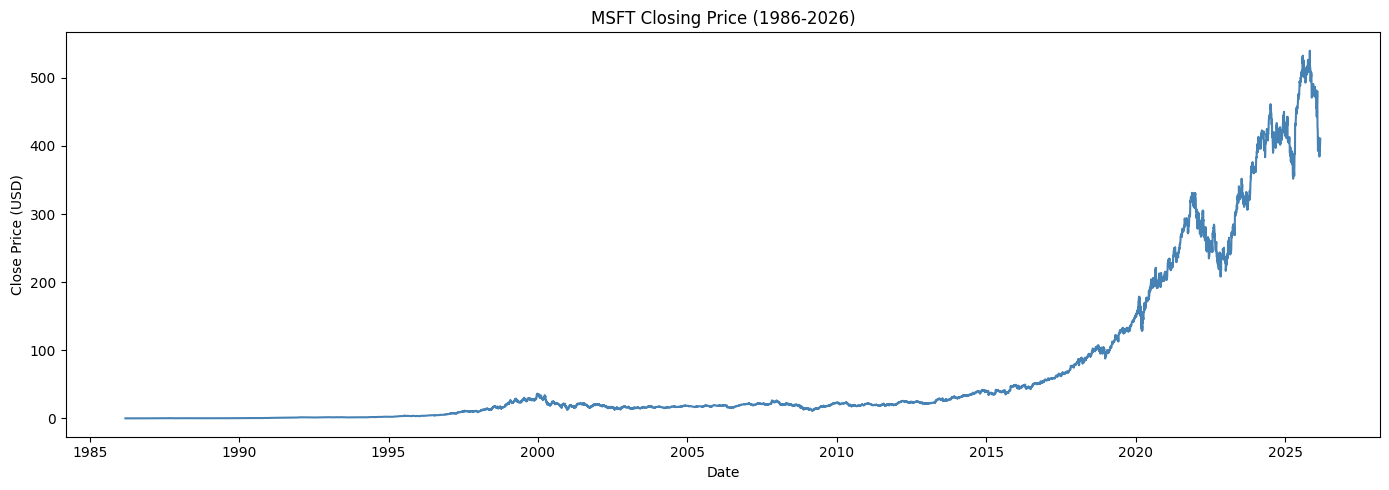

In [12]:
data["Date"] = pd.to_datetime(data["Date"])

plt.figure(figsize=(14, 5))
plt.plot(data["Date"], data["Close"], color="steelblue")
plt.title("MSFT Closing Price (1986-2026)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.tight_layout()
plt.show()

/Users/helmy/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/helmy/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/helmy/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/helmy/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

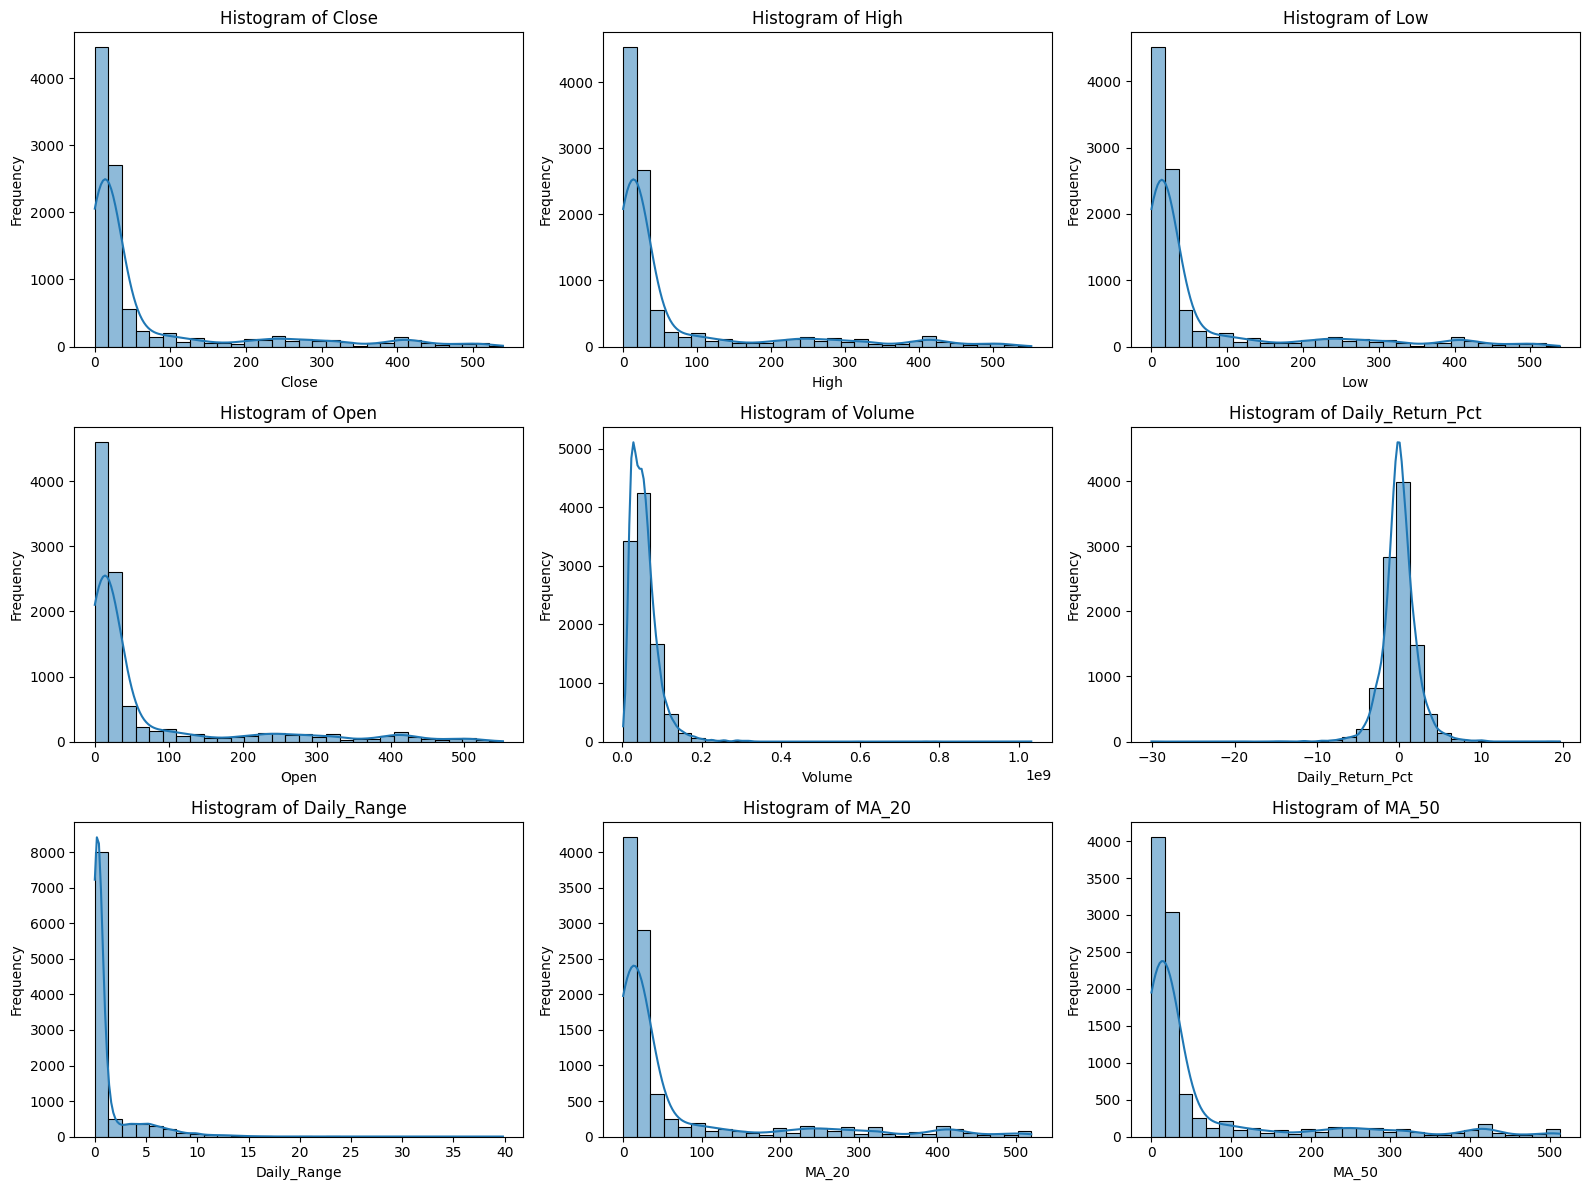

In [13]:
numerical_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

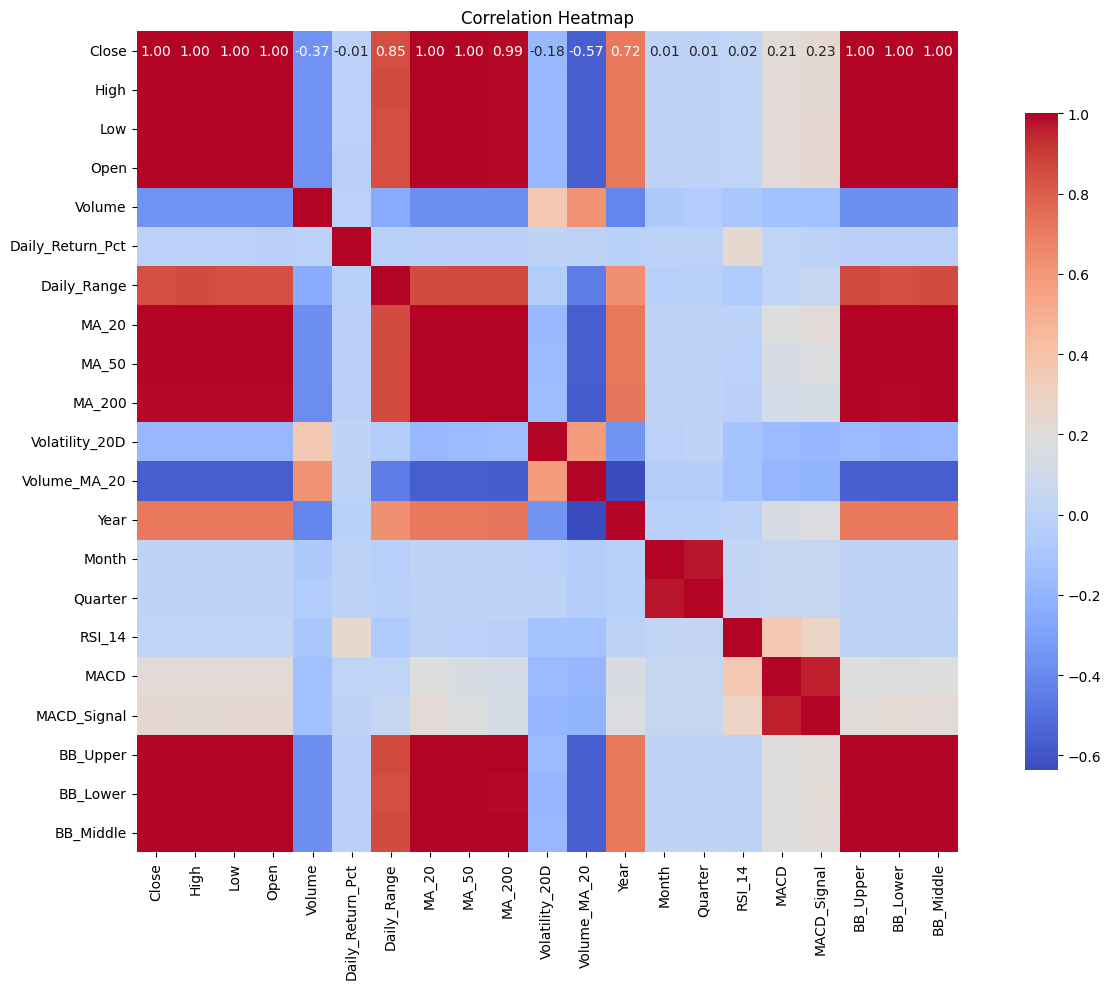

In [14]:
plt.figure(figsize=(14, 10))
corr = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

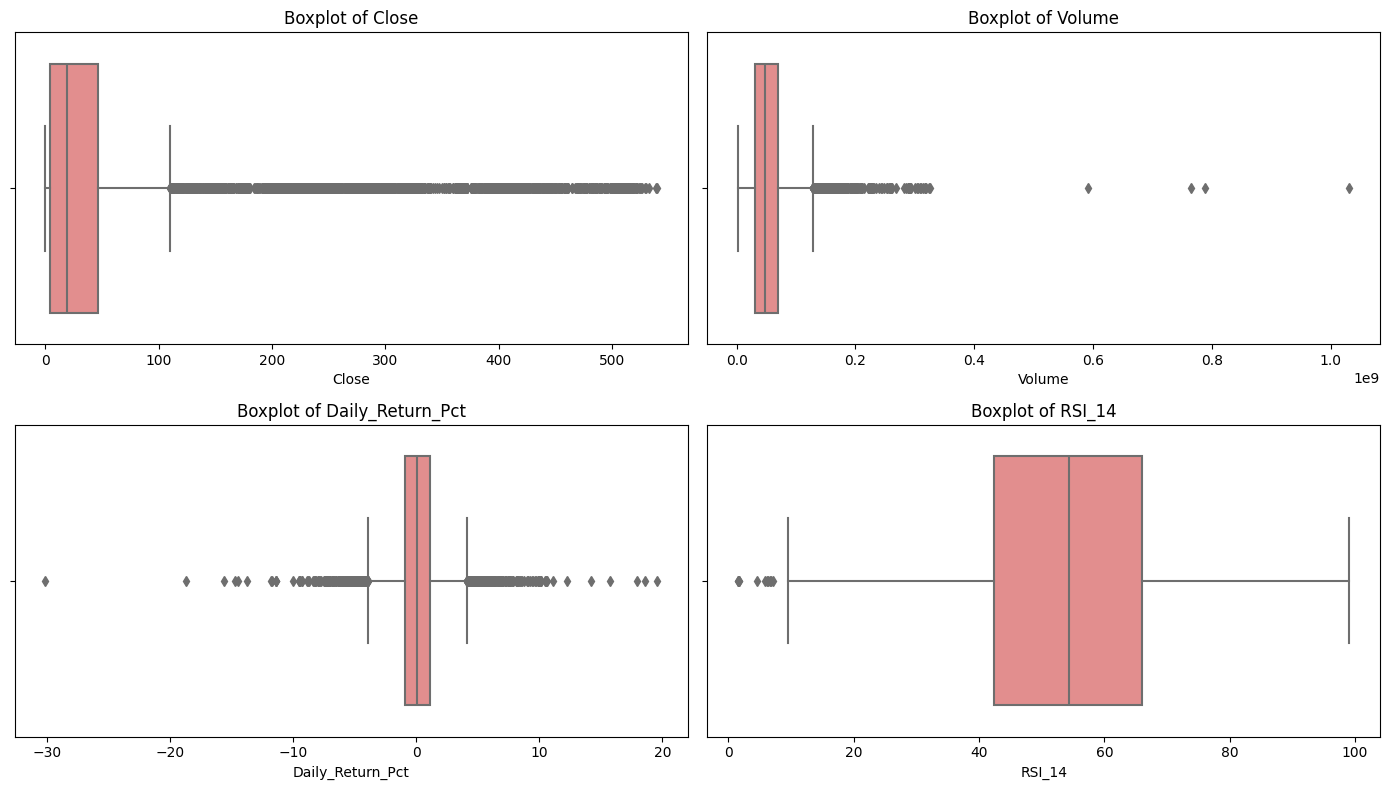

In [15]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(["Close", "Volume", "Daily_Return_Pct", "RSI_14"]):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=data[col], color="lightcoral")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [16]:
data = data.dropna().reset_index(drop=True)
data.isnull().sum().sum()

0

In [17]:
data = data.drop_duplicates().reset_index(drop=True)
data.duplicated().sum()

0

In [18]:
data = data.drop(columns=["Date", "Day_of_Week"])
data.head()

,Close,High,Low,Open,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,MA_200,...,Volume_MA_20,Year,Month,Quarter,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle
0,0.1045,0.1048,0.1042,0.1048,7027200,-0.2863,0.0006,0.1026,0.0932,0.0711,...,35373600.0,1986,12,4,50.84,0.0027,0.0032,0.1074,0.0978,0.1026
1,0.1042,0.1053,0.1042,0.1045,3715200,-0.2871,0.0011,0.1025,0.0938,0.0713,...,33619680.0,1986,12,4,51.41,0.0027,0.0031,0.1069,0.0980,0.1025
2,0.1000,0.1053,0.1000,0.1042,41702400,-4.0307,0.0053,0.1022,0.0943,0.0715,...,33638400.0,1986,12,4,43.75,0.0023,0.0029,0.1066,0.0979,0.1022
3,0.1010,0.1016,0.0989,0.1000,25401600,1.0000,0.0027,0.1021,0.0948,0.0717,...,32893920.0,1986,12,4,47.42,0.0020,0.0027,0.1065,0.0977,0.1021
4,0.1021,0.1037,0.1010,0.1010,23356800,1.0891,0.0027,0.1020,0.0953,0.0719,...,32623200.0,1986,12,4,48.15,0.0019,0.0026,0.1063,0.0977,0.1020


In [19]:
X = data.drop(columns=["Daily_Return_Pct"])
y = data["Daily_Return_Pct"]

print(f"Bentuk X: {X.shape}")
print(f"Bentuk y: {y.shape}")

Bentuk X: (9873, 20)
Bentuk y: (9873,)


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"Bentuk X_scaled: {X_scaled.shape}")
X_scaled.head()

Bentuk X_scaled: (9873, 20)


,Close,High,Low,Open,Volume,Daily_Range,MA_20,MA_50,MA_200,Volatility_20D,Volume_MA_20,Year,Month,Quarter,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle
0,-0.587395,-0.587855,-0.586926,-0.587298,-1.333823,-0.543005,-0.586566,-0.585611,-0.585677,-0.366460,-0.839365,-1.772182,1.5929,1.335787,-0.198862,-0.130312,-0.141007,-0.588094,-0.584385,-0.586566
1,-0.587398,-0.587851,-0.586926,-0.587300,-1.424338,-0.542806,-0.586567,-0.585606,-0.585675,-0.377383,-0.911332,-1.772182,1.5929,1.335787,-0.163660,-0.130312,-0.141054,-0.588098,-0.584384,-0.586567
2,-0.587434,-0.587851,-0.586962,-0.587303,-0.386173,-0.541137,-0.586569,-0.585601,-0.585673,-0.155017,-0.910564,-1.772182,1.5929,1.335787,-0.636729,-0.130489,-0.141148,-0.588100,-0.584384,-0.586569
3,-0.587425,-0.587882,-0.586971,-0.587338,-0.831663,-0.542170,-0.586570,-0.585597,-0.585671,-0.186548,-0.941111,-1.772182,1.5929,1.335787,-0.410076,-0.130622,-0.141242,-0.588101,-0.584386,-0.586570
4,-0.587416,-0.587865,-0.586953,-0.587330,-0.887546,-0.542170,-0.586571,-0.585593,-0.585669,-0.169649,-0.952219,-1.772182,1.5929,1.335787,-0.364992,-0.130666,-0.141289,-0.588103,-0.584386,-0.586571


In [21]:
for col in X_scaled.columns:
    Q1 = X_scaled[col].quantile(0.25)
    Q3 = X_scaled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_scaled[col] = np.where(X_scaled[col] < lower_bound, lower_bound, X_scaled[col])
    X_scaled[col] = np.where(X_scaled[col] > upper_bound, upper_bound, X_scaled[col])

X_scaled.head()

,Close,High,Low,Open,Volume,Daily_Range,MA_20,MA_50,MA_200,Volatility_20D,Volume_MA_20,Year,Month,Quarter,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle
0,-0.587395,-0.587855,-0.586926,-0.587298,-1.333823,-0.543005,-0.586566,-0.585611,-0.585677,-0.366460,-0.839365,-1.772182,1.5929,1.335787,-0.198862,-0.130312,-0.141007,-0.588094,-0.584385,-0.586566
1,-0.587398,-0.587851,-0.586926,-0.587300,-1.424338,-0.542806,-0.586567,-0.585606,-0.585675,-0.377383,-0.911332,-1.772182,1.5929,1.335787,-0.163660,-0.130312,-0.141054,-0.588098,-0.584384,-0.586567
2,-0.587434,-0.587851,-0.586962,-0.587303,-0.386173,-0.541137,-0.586569,-0.585601,-0.585673,-0.155017,-0.910564,-1.772182,1.5929,1.335787,-0.636729,-0.130489,-0.141148,-0.588100,-0.584384,-0.586569
3,-0.587425,-0.587882,-0.586971,-0.587338,-0.831663,-0.542170,-0.586570,-0.585597,-0.585671,-0.186548,-0.941111,-1.772182,1.5929,1.335787,-0.410076,-0.130622,-0.141242,-0.588101,-0.584386,-0.586570
4,-0.587416,-0.587865,-0.586953,-0.587330,-0.887546,-0.542170,-0.586571,-0.585593,-0.585669,-0.169649,-0.952219,-1.772182,1.5929,1.335787,-0.364992,-0.130666,-0.141289,-0.588103,-0.584386,-0.586571


In [22]:
processed = X_scaled.copy()
processed["Daily_Return_Pct"] = y.values
processed.to_csv("MSFT_preprocessing.csv", index=False)

print(f"Bentuk data preprocessing: {processed.shape}")
processed.head()

Bentuk data preprocessing: (9873, 21)


,Close,High,Low,Open,Volume,Daily_Range,MA_20,MA_50,MA_200,Volatility_20D,...,Year,Month,Quarter,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle,Daily_Return_Pct
0,-0.587395,-0.587855,-0.586926,-0.587298,-1.333823,-0.543005,-0.586566,-0.585611,-0.585677,-0.366460,...,-1.772182,1.5929,1.335787,-0.198862,-0.130312,-0.141007,-0.588094,-0.584385,-0.586566,-0.2863
1,-0.587398,-0.587851,-0.586926,-0.587300,-1.424338,-0.542806,-0.586567,-0.585606,-0.585675,-0.377383,...,-1.772182,1.5929,1.335787,-0.163660,-0.130312,-0.141054,-0.588098,-0.584384,-0.586567,-0.2871
2,-0.587434,-0.587851,-0.586962,-0.587303,-0.386173,-0.541137,-0.586569,-0.585601,-0.585673,-0.155017,...,-1.772182,1.5929,1.335787,-0.636729,-0.130489,-0.141148,-0.588100,-0.584384,-0.586569,-4.0307
3,-0.587425,-0.587882,-0.586971,-0.587338,-0.831663,-0.542170,-0.586570,-0.585597,-0.585671,-0.186548,...,-1.772182,1.5929,1.335787,-0.410076,-0.130622,-0.141242,-0.588101,-0.584386,-0.586570,1.0000
4,-0.587416,-0.587865,-0.586953,-0.587330,-0.887546,-0.542170,-0.586571,-0.585593,-0.585669,-0.169649,...,-1.772182,1.5929,1.335787,-0.364992,-0.130666,-0.141289,-0.588103,-0.584386,-0.586571,1.0891
